In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
%cd /mlx_devbox/users/janne.spijkervet/repo/44/samantha

/mlx_devbox/users/janne.spijkervet/repo/44/samantha


## LLaMA - Meta

In [5]:
import sys
sys.path.append("/mlx_devbox/users/janne.spijkervet/repo/44/samantha/meta-llama")

In [6]:
!nvidia-smi

Wed May 10 08:48:37 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 450.191.01   Driver Version: 450.191.01   CUDA Version: 11.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  A100-SXM-80GB       On   | 00000000:4A:00.0 Off |                    0 |
| N/A   37C    P0    91W / 400W |      0MiB / 81252MiB |      0%      Default |
|                               |                      |             Disabled |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [7]:
import os
from fairscale.nn.model_parallel.initialize import initialize_model_parallel
from llama import ModelArgs, Transformer, Tokenizer, LLaMA

from example import setup_model_parallel

os.environ["MASTER_ADDR"] = "localhost"
os.environ["MASTER_PORT"] = "1"
os.environ["LOCAL_RANK"] = "0"
os.environ["RANK"] = "0"
os.environ["WORLD_SIZE"] = "1"
local_rank, world_size = setup_model_parallel()


> initializing model parallel with size 1
> initializing ddp with size 1
> initializing pipeline with size 1


In [8]:
from pathlib import Path
ckpt_dir = "./downloads/llama/7B/"
tokenizer_path = "./downloads/llama/tokenizer.model"

checkpoints = sorted(Path(ckpt_dir).glob("*.pth"))
ckpt_path = checkpoints[local_rank]
torch_device = "cuda"
ckpt_path = "./downloads/llama/7B/llama-copy.pt"

In [9]:
import torch
import json

max_seq_len = 512
max_batch_size = 1
checkpoint = torch.load(ckpt_path, map_location="cpu")
with open(Path(ckpt_dir) / "params.json", "r") as f:
    params = json.loads(f.read())

model_args: ModelArgs = ModelArgs(
    max_seq_len=max_seq_len, max_batch_size=max_batch_size, **params
)
tokenizer = Tokenizer(model_path=tokenizer_path)
model_args.vocab_size = tokenizer.n_words
torch.set_default_tensor_type(torch.cuda.HalfTensor)
model = Transformer(model_args)
torch.set_default_tensor_type(torch.FloatTensor)
model.load_state_dict(checkpoint, strict=False)
generator = LLaMA(model, tokenizer)

In [10]:
temperature = 0.8
top_p = 0.95
torch.manual_seed(42)
results = generator.generate(
    ["I believe the meaning of life is"], max_gen_len=256, temperature=temperature, top_p=top_p
)

In [11]:
print(results[0])

I believe the meaning of life is to find meaning in your life. And ask yourself, what’s the worst thing that can happen? You die? Big deal, you’ll be gone. That’s it.
And, what’s the best thing that can happen? You live. You’re here. This is a gift.
So, make the most of it. Have fun.
And always, always, live life like you’re dying.
It’s a shame people wait until they’re on their deathbed to decide to start living.
Love is like a river. You can’t step into the same river twice, because every time you step into it, it’s a different river. And the same is true with love.
Love is a game that two can play, and a chase that both can run, but it’s a fine line between game and pain.
When you love someone, you love the whole package. Everything that person is. The good, the bad, and the ugly. And you don’t stop loving them because of their faults. You keep loving them because of their virtues.
Sometimes, the wrong person is the right person, because they are the one


## LLaMA - ByteDance

In [14]:
from samantha.byteformers.models import Llama, LlamaConfig
from recipes.byteformers_example.modules.language_modeling import LanguageModelingModule

2023-05-10 08:50:08,705 - torch.distributed.nn.jit.instantiator - INFO - Created a temporary directory at /tmp/tmpqu0jj6o8
2023-05-10 08:50:08,706 - torch.distributed.nn.jit.instantiator - INFO - Writing /tmp/tmpqu0jj6o8/_remote_module_non_scriptable.py


In [15]:
# Manual loading:
# config = LlamaConfig.from_name("7B")
# config.vocab_size = model_args.vocab_size
# config.rms_norm_epsilon = model_args.norm_eps
# config.logit_num = model_args.vocab_size
# config.attention_kwargs = {"enable_flash": True, "enable_mem_efficient": False}
# torch.set_default_tensor_type(torch.cuda.HalfTensor)
# model_bd = Llama(config)
# torch.set_default_tensor_type(torch.FloatTensor)
# print("Loading checkpoint from disk")
# checkpoint_bd = torch.load("./output/7B/llama.pt", map_location="cpu")
# model_bd.load_state_dict(checkpoint_bd, strict=False)

module_bd = LanguageModelingModule(
    model_name="7B",
    vocab_size=model_args.vocab_size,
    seq_len=256,
    learning_rate=None,
    warmup_steps=None,
    weight_decay=None,
    betas=None
)
module_bd = module_bd.to(torch_device)
model_bd = module_bd.model

Loading state dict...


In [16]:
model_bd = model_bd.to(torch_device)

In [17]:
batch_size = 1
seq_len = 7
token_sample = torch.randint(
    0,
    model_bd.config.vocab_size,
    size=(batch_size, seq_len),
    dtype=torch.int64,
    device=torch_device,
)

## Tokenizer

In [18]:
embed = model.tok_embeddings(token_sample)
embed_bd = model_bd.transformer.wte(token_sample)
torch.testing.assert_close(embed, embed_bd)

## LLaMA Block

We need to test the following components, in the order they will be pushe through the block:
1. RMSNorm (pre-norm)
2. MultiHeadAttention  
2.1 RotaryEmbedding
3. FFN

### RMSNorm

In [19]:
rms_norm_attn = model.layers[0].attention_norm
rms_norm_attn_bd = model_bd.transformer.h[0].ln_1

assert rms_norm_attn.eps == rms_norm_attn_bd.eps # this failed before! :(
rms_norm_attn_bd.eps = rms_norm_attn.eps

rms_attn = rms_norm_attn(embed)
rms_attn_bd = rms_norm_attn_bd(embed)

torch.testing.assert_close(rms_attn, rms_attn_bd)


rms_norm_ffn = model.layers[0].ffn_norm
rms_norm_ffn_bd = model_bd.transformer.h[0].ln_2

assert rms_norm_ffn.eps == rms_norm_ffn_bd.eps # this failed before! :(
rms_norm_attn_bd.eps = rms_norm_ffn.eps

rms_ffn = rms_norm_ffn(embed)
rms_ffn_bd = rms_norm_ffn_bd(embed)

torch.testing.assert_close(rms_ffn, rms_ffn_bd)

## MultiHeadAttention

### Prepare Rotary freqs + Mask

In [20]:
seq_len = token_sample.shape[1]
start_pos = 0
mask = torch.full((1, 1, seq_len, seq_len), float("-inf"), device=torch_device)
mask = torch.triu(mask, diagonal=1)

freqs_cis = model.freqs_cis[:seq_len]
freqs_cis = freqs_cis.to(torch_device)

### Perform e2e test - this fails!

In [21]:
mha = model.layers[0].attention
mha_bd = model_bd.transformer.h[0].attn
attn = mha(rms_attn, start_pos=0, freqs_cis=freqs_cis, mask=mask)

# mha_bd.rotary_embeddings.compute_cache(512*2)
attn_bd = mha_bd(rms_attn_bd)
torch.testing.assert_close(attn, attn_bd) # this fails, we need to go into the attention mechanism

### Decompose the LLaMA attention mechanism

#### QKV matrices

In [22]:
# Meta
bsz, seqlen, _ = rms_attn.shape
xq, xk, xv = mha.wq(rms_attn), mha.wk(rms_attn), mha.wv(rms_attn)

xq = xq.view(bsz, seqlen, mha.n_local_heads, mha.head_dim)
xk = xk.view(bsz, seqlen, mha.n_local_heads, mha.head_dim)
xv = xv.view(bsz, seqlen, mha.n_local_heads, mha.head_dim)

# ByteDance
xq_bd = mha_bd.to_q(rms_attn_bd)
xk_bd = mha_bd.to_k(rms_attn_bd)
xv_bd = mha_bd.to_v(rms_attn_bd)

xq_bd = mha_bd.rearrange_heads(xq_bd)
xk_bd = mha_bd.rearrange_heads(xk_bd)
xv_bd = mha_bd.rearrange_heads(xv_bd)


# Test. Meta's LLaMA uses a different MHA shape paradigm:
# [batch_size, n_heads, seq_len, head_dim]

# We use the following, so we swap (n_heads, seq_len)
# [batch_size, n_heads, seq_len, head_dim]
torch.testing.assert_close(xq, xq_bd.transpose(1,2))
torch.testing.assert_close(xk, xk_bd.transpose(1,2))
torch.testing.assert_close(xv, xv_bd.transpose(1,2))

#### Self-attention

In [23]:
# Meta:
import math
import torch.nn.functional as F
mha.cache_k = mha.cache_k.to(xq)
mha.cache_v = mha.cache_v.to(xq)

mha.cache_k[:bsz, start_pos : start_pos + seqlen] = xk
mha.cache_v[:bsz, start_pos : start_pos + seqlen] = xv

keys = mha.cache_k[:bsz, : start_pos + seqlen]
values = mha.cache_v[:bsz, : start_pos + seqlen]

scores = torch.matmul(xq.transpose(1, 2), keys.transpose(1, 2).transpose(2, 3)) / math.sqrt(mha.head_dim)
if mask is not None:
    scores = scores + mask  # (bs, n_local_heads, slen, cache_len + slen)
scores = F.softmax(scores.float(), dim=-1).type_as(xq)
output = torch.matmul(scores, values.transpose(1, 2))  # (bs, n_local_heads, slen, head_dim)
output = output.transpose(
    1, 2
).contiguous().view(bsz, seqlen, -1)

score = mha.wo(output)

# ByteDance:
score_bd = mha_bd.attention(xq_bd, xk_bd, xv_bd, return_attention=False)
torch.testing.assert_close(score, score_bd)

### RotaryEmbedding

/usr/local/lib/python3.9/dist-packages/torch/_tensor.py:972: ComplexWarning: Casting complex values to real discards the imaginary part
  return self.numpy().astype(dtype, copy=False)
/tmp/ipykernel_210/3084186886.py:24: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at ../aten/src/ATen/native/Copy.cpp:276.)
  plt.plot(freqs_cis_bd_complex[seq_idx, :64].cpu().float(), color="green", alpha=0.5, linestyle="--")


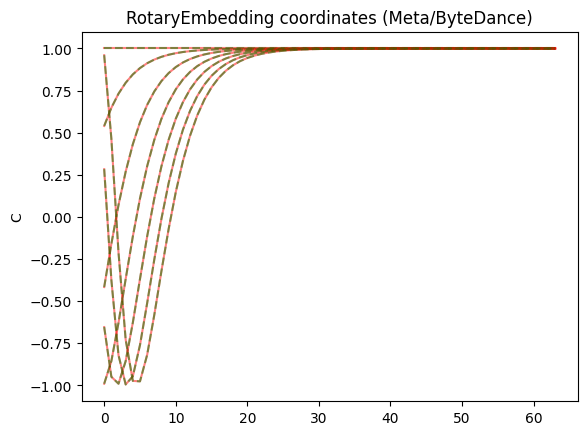

In [25]:
import matplotlib.pyplot as plt
from llama.model import apply_rotary_emb, reshape_for_broadcast
from samantha.byteformers.components.positional_embedding.rotary import apply_rotary_pos_emb, RotaryEmbedding

xq_rot, xk_rot = apply_rotary_emb(xq, xk, freqs_cis=freqs_cis)

rotary_bd = RotaryEmbedding(mha_bd.d_k, max_seq_len=seq_len).to(torch_device)
assert rotary_bd.inv_freq.shape[0] == freqs_cis.shape[1]


meta_freqs = 1.0 / (10000 ** (torch.arange(0, mha.head_dim, 2)[: (mha.head_dim // 2)].float() / mha.head_dim))
torch.testing.assert_close(meta_freqs.to(torch_device), rotary_bd.inv_freq)

torch.set_default_tensor_type(torch.cuda.HalfTensor)
freqs_cis_bd = rotary_bd._update_cos_sin_tables(xq_bd, seq_dimension=2)
freqs_cis_bd_complex = torch.view_as_complex(freqs_cis_bd)
torch.set_default_tensor_type(torch.FloatTensor)

freqs_cis_bd_complex = freqs_cis_bd_complex.squeeze()
torch.testing.assert_close(freqs_cis, freqs_cis_bd_complex)

for seq_idx in range(seqlen):
    plt.plot(freqs_cis[seq_idx, :64].cpu(), color="red", alpha=0.5)
    plt.plot(freqs_cis_bd_complex[seq_idx, :64].cpu().float(), color="green", alpha=0.5, linestyle="--")
    
plt.xlabel("")
plt.ylabel("C")
plt.title("RotaryEmbedding coordinates (Meta/ByteDance)")
plt.show()


xq_rot_bd = apply_rotary_pos_emb(xq_bd, freqs_cis_bd)
xk_rot_bd = apply_rotary_pos_emb(xk_bd, freqs_cis_bd)
torch.testing.assert_close(xq_rot, xq_rot_bd.transpose(1,2))
torch.testing.assert_close(xk_rot, xk_rot_bd.transpose(1,2))

### MHA End2End

In [26]:
mha_bd = model_bd.transformer.h[0].attn
attn = mha(rms_attn, start_pos=0, freqs_cis=freqs_cis, mask=mask)
attn_bd = mha_bd(rms_attn_bd)
torch.testing.assert_close(attn, attn_bd) # this fails, we need to go into the attention mechanism

## FFN

In [27]:
ffn = model.layers[0].feed_forward
ffn_bd = model_bd.transformer.h[0].mlp

ffn_out = ffn(rms_norm_ffn(attn))
ffn_out_bd = ffn(rms_norm_ffn(attn))

torch.testing.assert_close(ffn_out, ffn_out_bd)

## LLaMA Block End2End

In [28]:
# Redefine inputs, just in case:
embed = model.tok_embeddings(token_sample)
embed_bd = model_bd.transformer.wte(token_sample)


h = model.layers[0](embed, 0, freqs_cis, mask=mask)

# ByteDance
h_bd = model_bd.transformer.h[0](embed_bd)
torch.testing.assert_close(h, h_bd)

In [29]:
h = embed
h_bd = embed_bd

for layer_idx, (layer, layer_bd) in enumerate(zip(model.layers, model_bd.transformer.h)):
    h = layer(h, 0, freqs_cis, mask)
    h_bd = layer_bd(h_bd)
    
    print(layer_idx)
    torch.testing.assert_close(h, h_bd, atol=0, rtol=0)
    
    
h = model.norm(h)
h_bd = model_bd.transformer.ln_f(h_bd)
torch.testing.assert_close(h, h_bd, atol=0, rtol=0)

output = model.output(h[:, -1])
output_bd = model_bd.lm_head(h_bd[:, -1])
torch.testing.assert_close(output, output_bd, atol=0, rtol=0)
print("DONE")

0
1
2
3
4


AssertionError: Tensor-likes are not equal!

Mismatched elements: 1014 / 28672 (3.5%)
Greatest absolute difference: 0.00048828125 at index (0, 5, 3373)
Greatest relative difference: 0.2 at index (0, 5, 266)

## LLaMA End2End Generation

In [30]:
model = model.eval()

In [31]:
from llama import ModelArgs, Transformer, Tokenizer, LLaMA

model_bd.freqs_cis = torch.view_as_real(model.freqs_cis)

seq_len = 20
token_sample = torch.randint(
    0,
    model_bd.config.vocab_size,
    size=(batch_size, seq_len),
    dtype=torch.int64,
    device=torch_device,
)

with torch.no_grad():
    torch.manual_seed(42)
    outputs = model(token_sample, start_pos=0)
    
    torch.manual_seed(42)
    outputs_bd = model_bd(token_sample, last_logit_only=True)
    # print(outputs.shape, outputs_bd.shape)
    
# torch.testing.assert_close(outputs, outputs_bd[:, -1].float())
torch.testing.assert_close(outputs, outputs_bd.float())

# import matplotlib.pyplot as plt

# fig, ax = plt.subplots()

# diff = (outputs[0, -1] - outputs_bd[0, -1]).abs()

# plt.plot(diff.cpu()[:100])

# for idx in range(outputs_bd.shape[1]):
#     print(idx)
#     # torch.testing.assert_close(outputs[:, idx], outputs_bd[:, idx])
#     for layer_idx in range(outputs_bd.shape[2]):
#         if not torch.isclose(outputs[:, idx, layer_idx], outputs_bd[:, idx, layer_idx]):
#             print(layer_idx)
#             torch.testing.assert_close(outputs[:, idx, layer_idx], outputs_bd[:, idx, layer_idx])
#             # whaaaat???

AssertionError: Tensor-likes are not close!

Mismatched elements: 16344 / 32000 (51.1%)
Greatest absolute difference: 0.015625 at index (0, 55) (up to 1e-05 allowed)
Greatest relative difference: inf at index (0, 3840) (up to 1.3e-06 allowed)

In [32]:
# Meta
# Original:
torch.manual_seed(42)
results = generator.generate(
    ["I believe the meaning of life is"], max_gen_len=30, temperature=temperature, top_p=top_p
)
print(results[0])

I believe the meaning of life is to find meaning in your life. And ask yourself, what’s the worst thing that can happen? You die? Big deal, you’ll


In [33]:
%load_ext autoreload
# # Our wrapping:
from tqdm import tqdm
from recipes.byteformers_example.modules.language_modeling import sample_top_p
# from sami_ai.stages.module.byteformers.components.positional_embedding.rotary import precompute_freqs_cis

prompts = ["I believe the meaning of life is"]

# torch.set_default_tensor_type(torch.cuda.HalfTensor)
# model_bd.freqs_cis = precompute_freqs_cis(128, 1024)
# torch.set_default_tensor_type(torch.FloatTensor)
# torch.testing.assert_close(model.freqs_cis, model_bd.freqs_cis.to(model.freqs_cis.device))

prompt_tokens = torch.tensor([tokenizer.encode(x, bos=True, eos=False) for x in prompts], device=torch_device).long()
curr_inputs = prompt_tokens.clone()

prev_pos = 0
torch.manual_seed(42)

kv_cache = {}
max_new_tokens = 256
for cur_pos in tqdm(range(curr_inputs.shape[1], max_new_tokens), desc="Sampling"):
    # logits = model.forward(curr_inputs, prev_pos)
   
    logits = model_bd.forward(curr_inputs, kv_cache=kv_cache, last_logit_only=True)
    
    # torch.testing.assert_close(logits, logits_meta)
    logits = logits / temperature
    probs = logits.softmax(dim=-1)
    idx_next = sample_top_p(probs, top_p)
    curr_inputs = idx_next
    prompt_tokens = torch.cat((prompt_tokens, idx_next), dim=1)
    prev_pos = cur_pos

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Sampling: 100%|███████████████████████████████| 248/248 [00:10<00:00, 24.22it/s]


In [34]:
results_bd_wrap = tokenizer.decode(prompt_tokens.tolist())
print(results_bd_wrap[0])

I believe the meaning of life is to find meaning in your life. And ask yourself, what’s the worst thing that can happen? You die? Big deal, you’ll be gone. That’s it.
And, what’s the best thing that can happen? You live. You’re here. This is a gift.
So, make the most of it. Have fun.
And always, always, live life like you’re dying.
It’s a shame people wait until they’re on their deathbed to decide to start living.
Love is like a river. You can’t step into the same river twice, because every time you step into it, it’s a different river. And the same is true with love.
Love is a game that two can play, and a chase that just one can run.
Love is like a butterfly. The more you chase it, the more it will elude you. But if you just sit and watch it, it will come and land on you.
If you love someone, let them go. If they come back, they’re yours. If they don’t, they never were.



In [35]:
# ByteDance
torch.manual_seed(42)
prompt_tokens = torch.tensor([tokenizer.encode(x, bos=True, eos=False) for x in prompts], device=torch_device).long()
results_bd = module_bd.generate(prompt_tokens, max_new_tokens=256, temperature=0.8, do_sample=True, top_k=None, top_p=0.95)

Sampling: 100%|███████████████████████████████| 248/248 [00:09<00:00, 25.77it/s]


In [36]:
print(tokenizer.decode(results_bd.cpu().tolist())[0])

to find meaning in your life. And ask yourself, what’s the worst thing that can happen? You die? Big deal, you’ll be gone. That’s it.
And, what’s the best thing that can happen? You live. You’re here. This is a gift.
So, make the most of it. Have fun.
And always, always, live life like you’re dying.
It’s a shame people wait until they’re on their deathbed to decide to start living.
Love is like a river. You can’t step into the same river twice, because every time you step into it, it’s a different river. And the same is true with love.
Love is a game that two can play, and a chase that just one can run.
Love is like a butterfly. The more you chase it, the more it will elude you. But if you just sit and watch it, it will come and land on you.
If you love someone, let them go. If they come back, they’re yours. If they don’t, they never were.

